In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

print("All good!")

All good!


In [2]:
data = {
    'area': ['Patia', 'Saheed Nagar', 'Rasulgarh', 'Old Town', 'Chandrasekharpur', 'Nayapalli'],
    'temperature': [38, 41, 40, 43, 37, 39],
    'humidity': [65, 70, 68, 75, 60, 63],
    'ndvi': [0.4, 0.2, 0.15, 0.1, 0.5, 0.35],
    'population_density': [3000, 8000, 6000, 12000, 2500, 5000]
}

df = pd.DataFrame(data)
print(df)

               area  temperature  humidity  ndvi  population_density
0             Patia           38        65  0.40                3000
1      Saheed Nagar           41        70  0.20                8000
2         Rasulgarh           40        68  0.15                6000
3          Old Town           43        75  0.10               12000
4  Chandrasekharpur           37        60  0.50                2500
5         Nayapalli           39        63  0.35                5000


In [3]:
df['risk_score'] = (
    (df['temperature'] / df['temperature'].max()) * 0.4 +
    (df['humidity'] / df['humidity'].max()) * 0.2 +
    (1 - df['ndvi'] / df['ndvi'].max()) * 0.2 +
    (df['population_density'] / df['population_density'].max()) * 0.2
)

print(df[['area', 'risk_score']].sort_values('risk_score', ascending=False))

               area  risk_score
3          Old Town    0.960000
1      Saheed Nagar    0.821395
2         Rasulgarh    0.793426
5         Nayapalli    0.674124
0             Patia    0.616822
4  Chandrasekharpur    0.545853


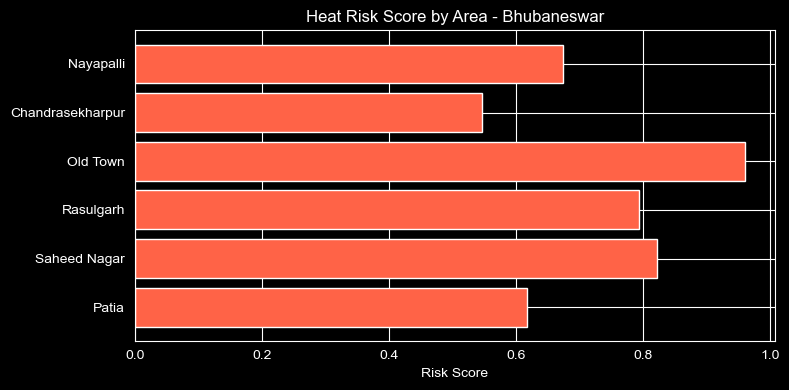

In [4]:
plt.figure(figsize=(8, 4))
plt.barh(df['area'], df['risk_score'], color='tomato')
plt.xlabel('Risk Score')
plt.title('Heat Risk Score by Area - Bhubaneswar')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans

features = df[['temperature', 'humidity', 'ndvi', 'population_density']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

print(df[['area', 'risk_score', 'cluster']])

               area  risk_score  cluster
0             Patia    0.616822        2
1      Saheed Nagar    0.821395        0
2         Rasulgarh    0.793426        0
3          Old Town    0.960000        1
4  Chandrasekharpur    0.545853        2
5         Nayapalli    0.674124        0


C:\Users\ACER\anaconda3\envs\heatlas\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
cluster_map = {1: 'High Risk', 0: 'Medium Risk', 2: 'Low Risk'}
df['risk_level'] = df['cluster'].map(cluster_map)

print(df[['area', 'risk_score', 'risk_level']])

               area  risk_score   risk_level
0             Patia    0.616822     Low Risk
1      Saheed Nagar    0.821395  Medium Risk
2         Rasulgarh    0.793426  Medium Risk
3          Old Town    0.960000    High Risk
4  Chandrasekharpur    0.545853     Low Risk
5         Nayapalli    0.674124  Medium Risk


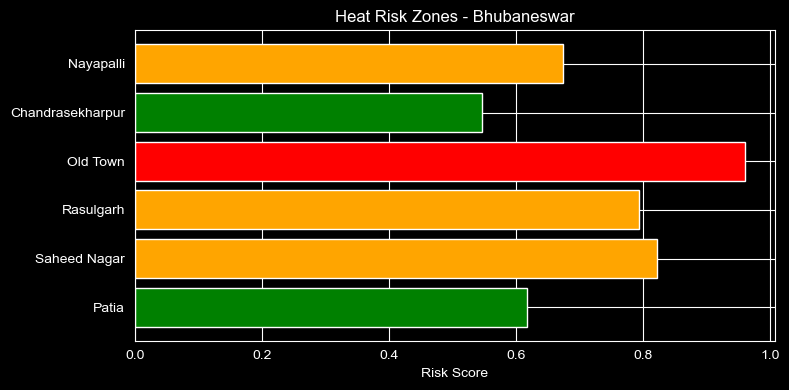

In [7]:
colors = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'}

plt.figure(figsize=(8, 4))
plt.barh(df['area'], df['risk_score'], color=df['risk_level'].map(colors))
plt.xlabel('Risk Score')
plt.title('Heat Risk Zones - Bhubaneswar')
plt.tight_layout()
plt.show()

In [8]:
import folium
print(folium.__version__)

0.20.0


In [9]:
# Neighborhood coordinates + data
neighborhoods = [
    {"name": "Patia",             "lat": 20.3534, "lon": 85.8161, "risk_score": 0.616822, "cluster": "Low Risk"},
    {"name": "Saheed Nagar",      "lat": 20.2961, "lon": 85.8245, "risk_score": 0.821395, "cluster": "Medium Risk"},
    {"name": "Rasulgarh",         "lat": 20.2847, "lon": 85.8351, "risk_score": 0.793426, "cluster": "Medium Risk"},
    {"name": "Old Town",          "lat": 20.2706, "lon": 85.8322, "risk_score": 0.960000, "cluster": "High Risk"},
    {"name": "Chandrasekharpur",  "lat": 20.3000, "lon": 85.8000, "risk_score": 0.545853, "cluster": "Low Risk"},
]

# Color mapping
def get_color(cluster):
    if cluster == "High Risk":
        return "red"
    elif cluster == "Medium Risk":
        return "orange"
    else:
        return "green"

# Map banao — Bhubaneswar center
m = folium.Map(location=[20.3, 85.82], zoom_start=12)

# Har neighborhood ka marker add karo
for n in neighborhoods:
    folium.CircleMarker(
        location=[n["lat"], n["lon"]],
        radius=15,
        color=get_color(n["cluster"]),
        fill=True,
        fill_opacity=0.7,
        popup=f"{n['name']}\nRisk Score: {n['risk_score']:.2f}\n{n['cluster']}"
    ).add_to(m)

m

In [10]:
import urllib.request
import json

url = "https://api.open-meteo.com/v1/forecast?latitude=20.2961&longitude=85.8245&current=temperature_2m,relative_humidity_2m&timezone=Asia%2FKolkata"

response = urllib.request.urlopen(url)
data = json.loads(response.read())
print(data)

{'latitude': 20.281195, 'longitude': 85.843376, 'generationtime_ms': 0.045418739318847656, 'utc_offset_seconds': 19800, 'timezone': 'Asia/Kolkata', 'timezone_abbreviation': 'GMT+5:30', 'elevation': 44.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'current': {'time': '2026-05-12T22:15', 'interval': 900, 'temperature_2m': 27.1, 'relative_humidity_2m': 84}}


In [11]:
current = data['current']
print("Temperature: " + str(current['temperature_2m']))
print("Humidity: " + str(current['relative_humidity_2m']))

Temperature: 27.1
Humidity: 84


In [12]:
def fetch_weather (lat, lon):
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,relative_humidity_2m&timezone=Asia%2FKolkata"
    response = urllib.request.urlopen(url)
    data = json.loads(response.read())
    return data['current']['temperature_2m'], data['current']['relative_humidity_2m']

#Testing for Patia
temp, humidity = fetch_weather(20.3534, 85.8161)
print("Patia - Temp: ", temp, "°C, Humidity:", humidity, "%")


Patia - Temp:  27.0 °C, Humidity: 84 %


In [13]:
neighborhoods = [
    {"name": "Patia",             "lat": 20.3534, "lon": 85.8161},
    {"name": "Saheed Nagar",      "lat": 20.2961, "lon": 85.8245},
    {"name": "Rasulgarh",         "lat": 20.2847, "lon": 85.8351},
    {"name": "Old Town",          "lat": 20.2706, "lon": 85.8322},
    {"name": "Chandrasekharpur",  "lat": 20.3000, "lon": 85.8000},
    {"name": "Nayapalli",         "lat": 20.2900, "lon": 85.8100},
    {"name": "Vani Vihar",        "lat": 20.2974, "lon": 85.8237},
    {"name": "Jaydev Vihar",      "lat": 20.3163, "lon": 85.8087},
    {"name": "IRC Village",       "lat": 20.3035, "lon": 85.8082},
    {"name": "Bapuji Nagar",      "lat": 20.2820, "lon": 85.8380},
    {"name": "Ashok Nagar",       "lat": 20.2716, "lon": 85.8408},
    {"name": "Kharavela Nagar",   "lat": 20.2680, "lon": 85.8350},
    {"name": "Bhouma Nagar",      "lat": 20.2750, "lon": 85.8450},
    {"name": "Keshari Nagar",     "lat": 20.2830, "lon": 85.8450},
    {"name": "Ganga Nagar",       "lat": 20.3100, "lon": 85.8200},
    {"name": "Surya Nagar",       "lat": 20.3050, "lon": 85.8150},
    {"name": "Bhoi Nagar",        "lat": 20.2780, "lon": 85.8300},
    {"name": "Acharya Vihar",     "lat": 20.2990, "lon": 85.8200},
    {"name": "Master Canteen",    "lat": 20.2647, "lon": 85.8362},
    {"name": "Kalinganagar",      "lat": 20.3300, "lon": 85.8200},
]

for n in neighborhoods:
    temp, humidity = fetch_weather(n["lat"], n["lon"])
    print(f"{n['name']} — Temp: {temp}°C, Humidity: {humidity}%")

Patia — Temp: 27.0°C, Humidity: 84%
Saheed Nagar — Temp: 27.1°C, Humidity: 84%
Rasulgarh — Temp: 27.1°C, Humidity: 84%
Old Town — Temp: 27.1°C, Humidity: 84%
Chandrasekharpur — Temp: 27.1°C, Humidity: 84%
Nayapalli — Temp: 27.1°C, Humidity: 84%
Vani Vihar — Temp: 27.1°C, Humidity: 84%
Jaydev Vihar — Temp: 27.0°C, Humidity: 84%
IRC Village — Temp: 27.1°C, Humidity: 84%
Bapuji Nagar — Temp: 27.1°C, Humidity: 84%
Ashok Nagar — Temp: 27.1°C, Humidity: 84%
Kharavela Nagar — Temp: 27.1°C, Humidity: 84%
Bhouma Nagar — Temp: 27.1°C, Humidity: 84%
Keshari Nagar — Temp: 27.1°C, Humidity: 84%
Ganga Nagar — Temp: 27.1°C, Humidity: 84%
Surya Nagar — Temp: 27.1°C, Humidity: 84%
Bhoi Nagar — Temp: 27.1°C, Humidity: 84%
Acharya Vihar — Temp: 27.1°C, Humidity: 84%
Master Canteen — Temp: 27.1°C, Humidity: 84%
Kalinganagar — Temp: 27.0°C, Humidity: 84%


In [14]:
weather_data = []
for n in neighborhoods:
    temp, humidity = fetch_weather(n["lat"], n["lon"])
    weather_data.append({
        'ID': n['name'].replace(' ', ''),
        'temperature': temp,
        'humidity': humidity
    })

weather_df = pd.DataFrame(weather_data)
print(weather_df)

                  ID  temperature  humidity
0              Patia         27.0        84
1        SaheedNagar         27.1        84
2          Rasulgarh         27.1        84
3            OldTown         27.1        84
4   Chandrasekharpur         27.1        84
5          Nayapalli         27.1        84
6          VaniVihar         27.1        84
7        JaydevVihar         27.0        84
8         IRCVillage         27.1        84
9        BapujiNagar         27.1        84
10        AshokNagar         27.1        84
11    KharavelaNagar         27.1        84
12       BhoumaNagar         27.1        84
13      KeshariNagar         27.1        84
14        GangaNagar         27.1        84
15        SuryaNagar         27.1        84
16         BhoiNagar         27.1        84
17      AcharyaVihar         27.1        84
18     MasterCanteen         27.1        84
19      Kalinganagar         27.0        84


In [15]:
import pandas as pd

rows = []
for n in neighborhoods:
    temp, humidity = fetch_weather(n["lat"], n["lon"])
    rows.append({
        "area": n["name"],
        "lat": n["lat"],
        "lon": n["lon"],
        "temperature": temp,
        "humidity": humidity,
        "ndvi": 0.4,           # estimated — baad mein replace karenge
        "population_density": 5000   # estimated — baad mein replace karenge
    })

df = pd.DataFrame(rows)
print(df)

                area      lat      lon  temperature  humidity  ndvi  \
0              Patia  20.3534  85.8161         27.0        84   0.4   
1       Saheed Nagar  20.2961  85.8245         27.1        84   0.4   
2          Rasulgarh  20.2847  85.8351         27.1        84   0.4   
3           Old Town  20.2706  85.8322         27.1        84   0.4   
4   Chandrasekharpur  20.3000  85.8000         27.1        84   0.4   
5          Nayapalli  20.2900  85.8100         27.1        84   0.4   
6         Vani Vihar  20.2974  85.8237         27.1        84   0.4   
7       Jaydev Vihar  20.3163  85.8087         27.0        84   0.4   
8        IRC Village  20.3035  85.8082         27.1        84   0.4   
9       Bapuji Nagar  20.2820  85.8380         27.1        84   0.4   
10       Ashok Nagar  20.2716  85.8408         27.1        84   0.4   
11   Kharavela Nagar  20.2680  85.8350         27.1        84   0.4   
12      Bhouma Nagar  20.2750  85.8450         27.1        84   0.4   
13    

In [16]:
# Normalization
df['temp_norm'] = df['temperature'] / df['temperature'].max()
df['humidity_norm'] = df['humidity'] / df['humidity'].max()
df['ndvi_norm'] = df['ndvi'] / df['ndvi'].max()
df['pop_norm'] = df['population_density'] / df['population_density'].max()

# Risk score
df['risk_score'] = (df['temp_norm'] * 0.4 +
                    df['humidity_norm'] * 0.2 +
                    (1 - df['ndvi_norm']) * 0.2 +
                    df['pop_norm'] * 0.2)

print(df[['area', 'temperature', 'humidity', 'risk_score']])

                area  temperature  humidity  risk_score
0              Patia         27.0        84    0.798524
1       Saheed Nagar         27.1        84    0.800000
2          Rasulgarh         27.1        84    0.800000
3           Old Town         27.1        84    0.800000
4   Chandrasekharpur         27.1        84    0.800000
5          Nayapalli         27.1        84    0.800000
6         Vani Vihar         27.1        84    0.800000
7       Jaydev Vihar         27.0        84    0.798524
8        IRC Village         27.1        84    0.800000
9       Bapuji Nagar         27.1        84    0.800000
10       Ashok Nagar         27.1        84    0.800000
11   Kharavela Nagar         27.1        84    0.800000
12      Bhouma Nagar         27.1        84    0.800000
13     Keshari Nagar         27.1        84    0.800000
14       Ganga Nagar         27.1        84    0.800000
15       Surya Nagar         27.1        84    0.800000
16        Bhoi Nagar         27.1        84    0

In [17]:
import csv

neighborhoods = [
    ("Patia", 20.3544, 85.8231),
    ("Saheed_Nagar", 20.2961, 85.8245),
    ("Rasulgarh", 20.2831, 85.8394),
    ("Old_Town", 20.2778, 85.8386),
    ("Chandrasekharpur", 20.3278, 85.7922),
    ("Nayapalli", 20.2961, 85.8078),
    ("Vani_Vihar", 20.3042, 85.8231),
    ("Jaydev_Vihar", 20.3319, 85.8078),
    ("IRC_Village", 20.3147, 85.8078),
    ("Bapuji_Nagar", 20.2681, 85.8394),
    ("Ashok_Nagar", 20.2778, 85.8231),
    ("Kharavela_Nagar", 20.2722, 85.8336),
    ("Bhouma_Nagar", 20.2611, 85.8281),
    ("Keshari_Nagar", 20.2833, 85.8461),
    ("Ganga_Nagar", 20.3089, 85.8144),
    ("Surya_Nagar", 20.2944, 85.8350),
    ("Bhoi_Nagar", 20.2681, 85.8231),
    ("Acharya_Vihar", 20.3042, 85.8078),
    ("Master_Canteen", 20.2722, 85.8394),
    ("Kalinganagar", 20.2611, 85.8461),
]

with open("bhubaneswar_coords.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["ID", "Category", "Latitude", "Longitude"])
    for name, lat, lon in neighborhoods:
        writer.writerow([name, "Bhubaneswar", lat, lon])

print("CSV ready!")

CSV ready!


In [18]:
import pandas as pd

df = pd.read_csv("bhubaneswar_coords.csv")
print(df)

                  ID     Category  Latitude  Longitude
0              Patia  Bhubaneswar   20.3544    85.8231
1       Saheed_Nagar  Bhubaneswar   20.2961    85.8245
2          Rasulgarh  Bhubaneswar   20.2831    85.8394
3           Old_Town  Bhubaneswar   20.2778    85.8386
4   Chandrasekharpur  Bhubaneswar   20.3278    85.7922
5          Nayapalli  Bhubaneswar   20.2961    85.8078
6         Vani_Vihar  Bhubaneswar   20.3042    85.8231
7       Jaydev_Vihar  Bhubaneswar   20.3319    85.8078
8        IRC_Village  Bhubaneswar   20.3147    85.8078
9       Bapuji_Nagar  Bhubaneswar   20.2681    85.8394
10       Ashok_Nagar  Bhubaneswar   20.2778    85.8231
11   Kharavela_Nagar  Bhubaneswar   20.2722    85.8336
12      Bhouma_Nagar  Bhubaneswar   20.2611    85.8281
13     Keshari_Nagar  Bhubaneswar   20.2833    85.8461
14       Ganga_Nagar  Bhubaneswar   20.3089    85.8144
15       Surya_Nagar  Bhubaneswar   20.2944    85.8350
16        Bhoi_Nagar  Bhubaneswar   20.2681    85.8231
17     Ach

In [19]:
import pandas as pd

ndvi_df = pd.read_csv("../data/samples/heatlas-ndvi-MOD13Q1-061-results.csv")
print(ndvi_df.shape)
print(ndvi_df['ID'].unique())

(140, 29)
<StringArray>
[    'AcharyaVihar',       'AshokNagar',      'BapujiNagar',
        'BhoiNagar',      'BhoumaNagar', 'Chandrasekharpur',
       'GangaNagar',       'IRCVillage',      'JaydevVihar',
     'Kalinganagar',     'KeshariNagar',   'KharavelaNagar',
    'MasterCanteen',        'Nayapalli',          'OldTown',
            'Patia',        'Rasulgarh',      'SaheedNagar',
       'SuryaNagar',        'VaniVihar']
Length: 20, dtype: str


In [20]:
ndvi_avg = ndvi_df.groupby('ID')['MOD13Q1_061__250m_16_days_NDVI'].mean()
print(ndvi_avg)

ID
AcharyaVihar        0.461586
AshokNagar          0.530871
BapujiNagar         0.563129
BhoiNagar           0.568143
BhoumaNagar         0.542729
Chandrasekharpur    0.740200
GangaNagar          0.444171
IRCVillage          0.614343
JaydevVihar         0.365014
Kalinganagar        0.366757
KeshariNagar        0.414214
KharavelaNagar      0.574514
MasterCanteen       0.539514
Nayapalli           0.404400
OldTown             0.430171
Patia               0.389543
Rasulgarh           0.511157
SaheedNagar         0.512629
SuryaNagar          0.447971
VaniVihar           0.453014
Name: MOD13Q1_061__250m_16_days_NDVI, dtype: float64


In [21]:
import rasterio
print("ok")

ok


In [22]:
with rasterio.open("../data/samples/ind_ppp_2020.tif") as src:
    print(src.crs)
    print(src.bounds)

EPSG:4326
BoundingBox(left=68.185416408, bottom=6.753750174, right=97.414582958, top=35.501250059)


In [23]:
import numpy as np

with rasterio.open("../data/samples/ind_ppp_2020.tif") as src:
    pop_data = []
    for idx, row in ndvi_avg.reset_index().iterrows():
        # ID column se naam lenge, coordinates CSV se
        name = row['ID']
        lat = ndvi_df[ndvi_df['ID'] == name]['Latitude'].values[0]
        lon = ndvi_df[ndvi_df['ID'] == name]['Longitude'].values[0]

        # rasterio se pixel value nikalo
        row_val, col_val = src.index(lon, lat)
        val = src.read(1)[row_val, col_val]
        pop_data.append({'ID': name, 'population_density': val})

pop_df = pd.DataFrame(pop_data)
print(pop_df)

                  ID  population_density
0       AcharyaVihar           49.626804
1         AshokNagar           64.439171
2        BapujiNagar           87.199783
3          BhoiNagar           60.041943
4        BhoumaNagar           58.656754
5   Chandrasekharpur            2.074183
6         GangaNagar           61.047081
7         IRCVillage           36.327221
8        JaydevVihar           29.924091
9       Kalinganagar          100.631889
10      KeshariNagar          130.122467
11    KharavelaNagar           91.311043
12     MasterCanteen          141.731689
13         Nayapalli          116.500626
14           OldTown           97.497719
15             Patia          108.456116
16         Rasulgarh           94.048012
17       SaheedNagar           82.757523
18        SuryaNagar           83.378036
19         VaniVihar           59.338242


In [22]:
pop_df.to_csv("../data/samples/population_density.csv", index=False)
print("saved!")

NameError: name 'pop_df' is not defined

In [21]:
# NDVI average already hai ndvi_avg mein
# Population already hai pop_df mein

# Merge karo
final_df = ndvi_avg.reset_index()
final_df.columns = ['ID', 'ndvi']
final_df = final_df.merge(pop_df, on='ID')
print(final_df)

NameError: name 'pop_df' is not defined

In [23]:
pop_df = pd.read_csv("../data/samples/population_density.csv")
print(pop_df.head())

             ID  population_density
0  AcharyaVihar           49.626804
1    AshokNagar           64.439170
2   BapujiNagar           87.199780
3     BhoiNagar           60.041943
4   BhoumaNagar           58.656754


In [24]:
final_df = ndvi_avg.reset_index()
final_df.columns = ['ID', 'ndvi']
final_df = final_df.merge(pop_df, on='ID')
print(final_df)

                  ID      ndvi  population_density
0       AcharyaVihar  0.461586           49.626804
1         AshokNagar  0.530871           64.439170
2        BapujiNagar  0.563129           87.199780
3          BhoiNagar  0.568143           60.041943
4        BhoumaNagar  0.542729           58.656754
5   Chandrasekharpur  0.740200            2.074183
6         GangaNagar  0.444171           61.047080
7         IRCVillage  0.614343           36.327220
8        JaydevVihar  0.365014           29.924091
9       Kalinganagar  0.366757          100.631890
10      KeshariNagar  0.414214          130.122470
11    KharavelaNagar  0.574514           91.311040
12     MasterCanteen  0.539514          141.731690
13         Nayapalli  0.404400          116.500626
14           OldTown  0.430171           97.497720
15             Patia  0.389543          108.456116
16         Rasulgarh  0.511157           94.048010
17       SaheedNagar  0.512629           82.757520
18        SuryaNagar  0.447971 

In [25]:
final_df = final_df.merge(weather_df, on='ID')
print(final_df)

                  ID      ndvi  population_density  temperature  humidity
0       AcharyaVihar  0.461586           49.626804         27.1        84
1         AshokNagar  0.530871           64.439170         27.1        84
2        BapujiNagar  0.563129           87.199780         27.1        84
3          BhoiNagar  0.568143           60.041943         27.1        84
4        BhoumaNagar  0.542729           58.656754         27.1        84
5   Chandrasekharpur  0.740200            2.074183         27.1        84
6         GangaNagar  0.444171           61.047080         27.1        84
7         IRCVillage  0.614343           36.327220         27.1        84
8        JaydevVihar  0.365014           29.924091         27.0        84
9       Kalinganagar  0.366757          100.631890         27.0        84
10      KeshariNagar  0.414214          130.122470         27.1        84
11    KharavelaNagar  0.574514           91.311040         27.1        84
12     MasterCanteen  0.539514        

In [26]:
# Normalization
final_df['ndvi_norm'] = final_df['ndvi'] / final_df['ndvi'].max()
final_df['pop_norm'] = final_df['population_density'] / final_df['population_density'].max()
final_df['temp_norm'] = final_df['temperature'] / final_df['temperature'].max()
final_df['hum_norm'] = final_df['humidity'] / final_df['humidity'].max()

# Risk Score
final_df['risk_score'] = (
    final_df['temp_norm'] * 0.4 +
    final_df['hum_norm'] * 0.2 +
    (1 - final_df['ndvi_norm']) * 0.2 +
    final_df['pop_norm'] * 0.2
)

print(final_df[['ID', 'risk_score']].sort_values('risk_score', ascending=False))

                  ID  risk_score
10      KeshariNagar    0.871698
13         Nayapalli    0.855128
12     MasterCanteen    0.854225
15             Patia    0.846315
9       Kalinganagar    0.841431
14           OldTown    0.821350
18        SuryaNagar    0.796616
16         Rasulgarh    0.794599
17       SaheedNagar    0.778270
11    KharavelaNagar    0.773618
2        BapujiNagar    0.770893
6         GangaNagar    0.766131
19         VaniVihar    0.761330
1         AshokNagar    0.747491
0       AcharyaVihar    0.745310
8        JaydevVihar    0.742125
4        BhoumaNagar    0.736128
3          BhoiNagar    0.731216
7         IRCVillage    0.685268
5   Chandrasekharpur    0.602927


In [27]:
final_df.to_csv("../data/samples/final_data.csv", index=False)
print("saved!")

saved!


In [28]:
import pandas as pd

df = pd.read_csv("../data/samples/final_data.csv")
print(df.head())
print(df.shape)

             ID      ndvi  population_density  temperature  humidity  \
0  AcharyaVihar  0.461586           49.626804         27.1        84   
1    AshokNagar  0.530871           64.439170         27.1        84   
2   BapujiNagar  0.563129           87.199780         27.1        84   
3     BhoiNagar  0.568143           60.041943         27.1        84   
4   BhoumaNagar  0.542729           58.656754         27.1        84   

   ndvi_norm  pop_norm  temp_norm  hum_norm  risk_score  
0   0.623596  0.350146        1.0       1.0    0.745310  
1   0.717200  0.454656        1.0       1.0    0.747491  
2   0.760779  0.615245        1.0       1.0    0.770893  
3   0.767553  0.423631        1.0       1.0    0.731216  
4   0.733219  0.413858        1.0       1.0    0.736128  
(20, 10)


In [29]:
from sklearn.cluster import KMeans

features = df[["ndvi_norm", "pop_norm", "temp_norm", "hum_norm"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(features)

print(df[["ID", "risk_score", "cluster"]].sort_values("risk_score", ascending=False))

                  ID  risk_score  cluster
10      KeshariNagar    0.871698        0
13         Nayapalli    0.855128        0
12     MasterCanteen    0.854225        0
15             Patia    0.846315        0
9       Kalinganagar    0.841431        0
14           OldTown    0.821350        0
18        SuryaNagar    0.796616        0
16         Rasulgarh    0.794599        0
17       SaheedNagar    0.778270        0
11    KharavelaNagar    0.773618        0
2        BapujiNagar    0.770893        0
6         GangaNagar    0.766131        1
19         VaniVihar    0.761330        1
1         AshokNagar    0.747491        1
0       AcharyaVihar    0.745310        1
8        JaydevVihar    0.742125        1
4        BhoumaNagar    0.736128        1
3          BhoiNagar    0.731216        1
7         IRCVillage    0.685268        1
5   Chandrasekharpur    0.602927        2


C:\Users\ACER\anaconda3\envs\heatlas\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [30]:
kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans2.fit_predict(df[["risk_score"]])
print(df[["ID", "risk_score", "cluster"]].sort_values("risk_score", ascending=False))

                  ID  risk_score  cluster
10      KeshariNagar    0.871698        1
13         Nayapalli    0.855128        1
12     MasterCanteen    0.854225        1
15             Patia    0.846315        1
9       Kalinganagar    0.841431        1
14           OldTown    0.821350        1
18        SuryaNagar    0.796616        2
16         Rasulgarh    0.794599        2
17       SaheedNagar    0.778270        2
11    KharavelaNagar    0.773618        2
2        BapujiNagar    0.770893        2
6         GangaNagar    0.766131        2
19         VaniVihar    0.761330        2
1         AshokNagar    0.747491        2
0       AcharyaVihar    0.745310        2
8        JaydevVihar    0.742125        2
4        BhoumaNagar    0.736128        2
3          BhoiNagar    0.731216        2
7         IRCVillage    0.685268        0
5   Chandrasekharpur    0.602927        0


C:\Users\ACER\anaconda3\envs\heatlas\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:
print(df.groupby("cluster")["risk_score"].mean().sort_values(ascending=False))

cluster
1    0.848358
2    0.761977
0    0.644098
Name: risk_score, dtype: float64


In [32]:
cluster_map = {1: "High", 2: "Medium", 0: "Low"}
df["risk_label"] = df["cluster"].map(cluster_map)
print(df[["ID", "risk_score", "risk_label"]].sort_values("risk_score", ascending=False))

                  ID  risk_score risk_label
10      KeshariNagar    0.871698       High
13         Nayapalli    0.855128       High
12     MasterCanteen    0.854225       High
15             Patia    0.846315       High
9       Kalinganagar    0.841431       High
14           OldTown    0.821350       High
18        SuryaNagar    0.796616     Medium
16         Rasulgarh    0.794599     Medium
17       SaheedNagar    0.778270     Medium
11    KharavelaNagar    0.773618     Medium
2        BapujiNagar    0.770893     Medium
6         GangaNagar    0.766131     Medium
19         VaniVihar    0.761330     Medium
1         AshokNagar    0.747491     Medium
0       AcharyaVihar    0.745310     Medium
8        JaydevVihar    0.742125     Medium
4        BhoumaNagar    0.736128     Medium
3          BhoiNagar    0.731216     Medium
7         IRCVillage    0.685268        Low
5   Chandrasekharpur    0.602927        Low


In [33]:
import os
os.makedirs("outputs", exist_ok=True)

In [34]:
import folium

# Color mapping
color_map = {"High": "red", "Medium": "orange", "Low": "green"}

# Coordinates — same as before
coords = {
    "AcharyaVihar": (20.2961, 85.8245),
    "AshokNagar": (20.2700, 85.8400),
    "BapujiNagar": (20.2580, 85.8350),
    "BhoiNagar": (20.3050, 85.8200),
    "BhoumaNagar": (20.2750, 85.8150),
    "Chandrasekharpur": (20.3200, 85.7800),
    "GangaNagar": (20.2850, 85.7950),
    "IRCVillage": (20.3100, 85.8050),
    "JaydevVihar": (20.3000, 85.8180),
    "Kalinganagar": (20.2650, 85.8100),
    "KeshariNagar": (20.2550, 85.8300),
    "KharavelaNagar": (20.2620, 85.8420),
    "MasterCanteen": (20.2700, 85.8480),
    "Nayapalli": (20.2900, 85.8100),
    "OldTown": (20.2450, 85.8650),
    "Patia": (20.3500, 85.8200),
    "Rasulgarh": (20.2800, 85.8450),
    "SaheedNagar": (20.2750, 85.8380),
    "SuryaNagar": (20.2680, 85.8200),
    "VaniVihar": (20.3020, 85.8300),
}

m = folium.Map(location=[20.2961, 85.8245], zoom_start=12)

for _, row in df.iterrows():
    lat, lon = coords[row["ID"]]
    folium.CircleMarker(
        location=[lat, lon],
        radius=10,
        color=color_map[row["risk_label"]],
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(f"""
    <b>{row['ID']}</b><br>
    Risk: {row['risk_label']}<br>
    Score: {round(row['risk_score'], 3)}<br>
    Temp: {row['temperature']}°C<br>
    NDVI: {round(row['ndvi'], 3)}<br>
    Population Density: {round(row['population_density'], 1)}
""", max_width=200)
    ).add_to(m)

m.save("outputs/heatlas_map.html")
print("Map saved!")

Map saved!


In [35]:
import pandas as pd

df = pd.read_csv("../data/samples/final_data.csv")
print(df.head())
print(df.columns.tolist())

             ID      ndvi  population_density  temperature  humidity  \
0  AcharyaVihar  0.461586           49.626804         27.1        84   
1    AshokNagar  0.530871           64.439170         27.1        84   
2   BapujiNagar  0.563129           87.199780         27.1        84   
3     BhoiNagar  0.568143           60.041943         27.1        84   
4   BhoumaNagar  0.542729           58.656754         27.1        84   

   ndvi_norm  pop_norm  temp_norm  hum_norm  risk_score  
0   0.623596  0.350146        1.0       1.0    0.745310  
1   0.717200  0.454656        1.0       1.0    0.747491  
2   0.760779  0.615245        1.0       1.0    0.770893  
3   0.767553  0.423631        1.0       1.0    0.731216  
4   0.733219  0.413858        1.0       1.0    0.736128  
['ID', 'ndvi', 'population_density', 'temperature', 'humidity', 'ndvi_norm', 'pop_norm', 'temp_norm', 'hum_norm', 'risk_score']


In [36]:
import urllib.request
import json

def fetch_forecast(lat, lon):
    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&daily=temperature_2m_max,relative_humidity_2m_max"
        f"&forecast_days=7"
        f"&timezone=Asia%2FKolkata"
    )
    with urllib.request.urlopen(url) as response:
        data = json.loads(response.read())
    return data["daily"]

# Test karo ek neighborhood pe
test = fetch_forecast(20.3380, 85.8045)
print(test)

{'time': ['2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17', '2026-05-18'], 'temperature_2m_max': [34.0, 34.3, 36.0, 37.5, 37.5, 39.8, 39.5], 'relative_humidity_2m_max': [93, 93, 88, 88, 87, 90, 92]}


In [37]:
coords_df = pd.read_csv("../notebooks/bhubaneswar_coords.csv")
print(coords_df.head())
print(coords_df.columns.tolist())

                 ID     Category  Latitude  Longitude
0             Patia  Bhubaneswar   20.3544    85.8231
1      Saheed_Nagar  Bhubaneswar   20.2961    85.8245
2         Rasulgarh  Bhubaneswar   20.2831    85.8394
3          Old_Town  Bhubaneswar   20.2778    85.8386
4  Chandrasekharpur  Bhubaneswar   20.3278    85.7922
['ID', 'Category', 'Latitude', 'Longitude']


In [38]:
import time

forecast_records = []

for _, row in coords_df.iterrows():
    daily = fetch_forecast(row["Latitude"], row["Longitude"])
    for i in range(7):
        forecast_records.append({
            "neighborhood": row["ID"],
            "date": daily["time"][i],
            "temperature": daily["temperature_2m_max"][i],
            "humidity": daily["relative_humidity_2m_max"][i],
        })
    time.sleep(0.3)

forecast_df = pd.DataFrame(forecast_records)
print(forecast_df.shape)
print(forecast_df.head(10))

(140, 4)
   neighborhood        date  temperature  humidity
0         Patia  2026-05-12         34.0        93
1         Patia  2026-05-13         34.3        93
2         Patia  2026-05-14         36.0        88
3         Patia  2026-05-15         37.5        88
4         Patia  2026-05-16         37.5        87
5         Patia  2026-05-17         39.8        90
6         Patia  2026-05-18         39.5        92
7  Saheed_Nagar  2026-05-12         33.9        92
8  Saheed_Nagar  2026-05-13         34.2        93
9  Saheed_Nagar  2026-05-14         35.7        87


In [39]:
# df mein se sirf NDVI aur population chahiye
ndvi_pop = df[["ID", "ndvi", "population_density"]]

# merge karo neighborhood ke basis pe
forecast_df = forecast_df.merge(ndvi_pop, left_on="neighborhood", right_on="ID")
print(forecast_df.head())

  neighborhood        date  temperature  humidity     ID      ndvi  \
0        Patia  2026-05-12         34.0        93  Patia  0.389543   
1        Patia  2026-05-13         34.3        93  Patia  0.389543   
2        Patia  2026-05-14         36.0        88  Patia  0.389543   
3        Patia  2026-05-15         37.5        88  Patia  0.389543   
4        Patia  2026-05-16         37.5        87  Patia  0.389543   

   population_density  
0          108.456116  
1          108.456116  
2          108.456116  
3          108.456116  
4          108.456116  


In [40]:
# max values se normalize karo
max_temp = forecast_df["temperature"].max()
max_hum = forecast_df["humidity"].max()
max_ndvi = forecast_df["ndvi"].max()
max_pop = forecast_df["population_density"].max()

# normalize
forecast_df["temp_norm"] = forecast_df["temperature"] / max_temp
forecast_df["hum_norm"] = forecast_df["humidity"] / max_hum
forecast_df["ndvi_norm"] = forecast_df["ndvi"] / max_ndvi
forecast_df["pop_norm"] = forecast_df["population_density"] / max_pop

# risk score
forecast_df["risk_score"] = (
    forecast_df["temp_norm"] * 0.4 +
    forecast_df["hum_norm"] * 0.2 +
    (1 - forecast_df["ndvi_norm"]) * 0.2 +
    forecast_df["pop_norm"] * 0.2
)

print(forecast_df[["neighborhood", "date", "temperature", "risk_score"]].head(10))

  neighborhood        date  temperature  risk_score
0        Patia  2026-05-12         34.0    0.814611
1        Patia  2026-05-13         34.3    0.817574
2        Patia  2026-05-14         36.0    0.823726
3        Patia  2026-05-15         37.5    0.838541
4        Patia  2026-05-16         37.5    0.836413
5        Patia  2026-05-17         39.8    0.865512
6        Patia  2026-05-18         39.5    0.866804
7    Rasulgarh  2026-05-12         33.9    0.753901
8    Rasulgarh  2026-05-13         34.2    0.758992
9    Rasulgarh  2026-05-14         35.7    0.761041


In [41]:
print(forecast_df[["neighborhood", "date", "temperature", "risk_score"]].tail(10))
print(forecast_df.shape)

    neighborhood        date  temperature  risk_score
25     Nayapalli  2026-05-16         37.2    0.843246
26     Nayapalli  2026-05-17         40.5    0.880094
27     Nayapalli  2026-05-18         39.9    0.880551
28  Kalinganagar  2026-05-12         33.9    0.804220
29  Kalinganagar  2026-05-13         34.2    0.809311
30  Kalinganagar  2026-05-14         35.7    0.811360
31  Kalinganagar  2026-05-15         37.4    0.828150
32  Kalinganagar  2026-05-16         37.2    0.826175
33  Kalinganagar  2026-05-17         40.5    0.863023
34  Kalinganagar  2026-05-18         39.9    0.863480
(35, 12)


In [42]:
print(forecast_df["neighborhood"].nunique())
print(df["ID"].unique())

5
<StringArray>
[    'AcharyaVihar',       'AshokNagar',      'BapujiNagar',
        'BhoiNagar',      'BhoumaNagar', 'Chandrasekharpur',
       'GangaNagar',       'IRCVillage',      'JaydevVihar',
     'Kalinganagar',     'KeshariNagar',   'KharavelaNagar',
    'MasterCanteen',        'Nayapalli',          'OldTown',
            'Patia',        'Rasulgarh',      'SaheedNagar',
       'SuryaNagar',        'VaniVihar']
Length: 20, dtype: str


In [43]:
coords_df["ID"] = coords_df["ID"].str.replace("_", "")
print(coords_df["ID"].unique())


<StringArray>
[           'Patia',      'SaheedNagar',        'Rasulgarh',
          'OldTown', 'Chandrasekharpur',        'Nayapalli',
        'VaniVihar',      'JaydevVihar',       'IRCVillage',
      'BapujiNagar',       'AshokNagar',   'KharavelaNagar',
      'BhoumaNagar',     'KeshariNagar',       'GangaNagar',
       'SuryaNagar',        'BhoiNagar',     'AcharyaVihar',
    'MasterCanteen',     'Kalinganagar']
Length: 20, dtype: str


In [44]:
forecast_records = []

for _, row in coords_df.iterrows():
    daily = fetch_forecast(row["Latitude"], row["Longitude"])
    for i in range(7):
        forecast_records.append({
            "neighborhood": row["ID"],
            "date": daily["time"][i],
            "temperature": daily["temperature_2m_max"][i],
            "humidity": daily["relative_humidity_2m_max"][i],
        })
    time.sleep(0.3)

forecast_df = pd.DataFrame(forecast_records)

# merge
ndvi_pop = df[["ID", "ndvi", "population_density"]]
forecast_df = forecast_df.merge(ndvi_pop, left_on="neighborhood", right_on="ID")

print(forecast_df.shape)

(140, 7)


In [45]:
max_temp = forecast_df["temperature"].max()
max_hum = forecast_df["humidity"].max()
max_ndvi = forecast_df["ndvi"].max()
max_pop = forecast_df["population_density"].max()

forecast_df["temp_norm"] = forecast_df["temperature"] / max_temp
forecast_df["hum_norm"] = forecast_df["humidity"] / max_hum
forecast_df["ndvi_norm"] = forecast_df["ndvi"] / max_ndvi
forecast_df["pop_norm"] = forecast_df["population_density"] / max_pop

forecast_df["risk_score"] = (
    forecast_df["temp_norm"] * 0.4 +
    forecast_df["hum_norm"] * 0.2 +
    (1 - forecast_df["ndvi_norm"]) * 0.2 +
    forecast_df["pop_norm"] * 0.2
)

print(forecast_df[["neighborhood", "date", "temperature", "risk_score"]].head(14))

   neighborhood        date  temperature  risk_score
0         Patia  2026-05-10         32.7    0.803932
1         Patia  2026-05-11         33.9    0.813105
2         Patia  2026-05-12         34.5    0.823877
3         Patia  2026-05-13         34.3    0.819599
4         Patia  2026-05-14         35.3    0.832741
5         Patia  2026-05-15         36.1    0.839543
6         Patia  2026-05-16         35.5    0.837019
7   SaheedNagar  2026-05-10         32.7    0.738535
8   SaheedNagar  2026-05-11         33.7    0.743429
9   SaheedNagar  2026-05-12         34.5    0.754356
10  SaheedNagar  2026-05-13         34.4    0.751186
11  SaheedNagar  2026-05-14         35.2    0.762112
12  SaheedNagar  2026-05-15         35.9    0.765744
13  SaheedNagar  2026-05-16         35.5    0.767498


In [46]:
daily_high_risk = forecast_df.loc[forecast_df.groupby("date")["risk_score"].idxmax()]
print(daily_high_risk[["date", "neighborhood", "temperature", "risk_score"]])

          date  neighborhood  temperature  risk_score
91  2026-05-10  KeshariNagar         32.7    0.831963
92  2026-05-11  KeshariNagar         33.7    0.836858
93  2026-05-12  KeshariNagar         34.5    0.847784
94  2026-05-13  KeshariNagar         34.4    0.844614
95  2026-05-14  KeshariNagar         35.2    0.855541
96  2026-05-15  KeshariNagar         35.9    0.859173
97  2026-05-16  KeshariNagar         35.5    0.860927


In [47]:
import os
os.makedirs("../outputs", exist_ok=True)

forecast_df.to_csv("../outputs/forecast_7day.csv", index=False)
print("Saved!")

Saved!


In [48]:
summary = (
    forecast_df.groupby("neighborhood")["risk_score"]
    .mean()
    .reset_index()
    .sort_values("risk_score", ascending=False)
    .reset_index(drop=True)
)
print(summary)

        neighborhood  risk_score
0       KeshariNagar    0.848123
1          Nayapalli    0.831553
2      MasterCanteen    0.830649
3              Patia    0.824259
4       Kalinganagar    0.819331
5            OldTown    0.797774
6         SuryaNagar    0.773040
7          Rasulgarh    0.771024
8        SaheedNagar    0.754694
9     KharavelaNagar    0.750043
10       BapujiNagar    0.747318
11        GangaNagar    0.742555
12         VaniVihar    0.737755
13        AshokNagar    0.723916
14      AcharyaVihar    0.721735
15       JaydevVihar    0.720069
16       BhoumaNagar    0.712552
17         BhoiNagar    0.707640
18        IRCVillage    0.661737
19  Chandrasekharpur    0.579171


In [56]:
import folium

summary = summary.merge(coords_df[["ID", "Latitude", "Longitude"]],
                        left_on="neighborhood", right_on="ID")

m = folium.Map(location=[20.3, 85.82], zoom_start=12)

for _, row in summary.iterrows():
    if row["risk_score"] >= 0.80:
        color = "red"
    elif row["risk_score"] >= 0.73:
        color = "orange"
    else:
        color = "green"

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=8,
        color=color,
        fill=True,
        popup=f"{row['neighborhood']}<br>Avg Risk: {row['risk_score']:.3f}"
    ).add_to(m)

m.save("../outputs/forecast_map.html")
print("Map saved!")

MergeError: Passing 'suffixes' which cause duplicate columns {'Longitude_x', 'Latitude_y', 'Longitude_y', 'Latitude_x'} is not allowed.

In [46]:
print(summary.columns.tolist())

NameError: name 'summary' is not defined

In [45]:
summary = summary[["neighborhood", "risk_score", "Latitude_x", "Longitude_x"]]
summary = summary.rename(columns={"Latitude_x": "Latitude", "Longitude_x": "Longitude"})
print(summary.head())

NameError: name 'summary' is not defined

In [57]:
import folium

# coords se sirf zaroori columns lo
coords_clean = coords_df[["ID", "Latitude", "Longitude"]].copy()
coords_clean["ID"] = coords_clean["ID"].str.replace("_", "")

# summary ke saath merge
map_df = summary[["neighborhood", "risk_score"]].merge(
    coords_clean, left_on="neighborhood", right_on="ID"
)

print(map_df.shape)
print(map_df.head())

(20, 5)
    neighborhood  risk_score             ID  Latitude  Longitude
0   KeshariNagar    0.848123   KeshariNagar   20.2833    85.8461
1      Nayapalli    0.831553      Nayapalli   20.2961    85.8078
2  MasterCanteen    0.830649  MasterCanteen   20.2722    85.8394
3          Patia    0.824259          Patia   20.3544    85.8231
4   Kalinganagar    0.819331   Kalinganagar   20.2611    85.8461


In [60]:
m = folium.Map(location=[20.3, 85.82], zoom_start=12)

for _, row in map_df.iterrows():
    if row["risk_score"] >= 0.80:
        color = "red"
    elif row["risk_score"] >= 0.73:
        color = "orange"
    else:
        color = "green"

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=8,
        color=color,
        fill=True,
        popup=f"{row['neighborhood']}<br>Avg Risk (7-day): {row['risk_score']:.3f}"
    ).add_to(m)

m.save("../outputs/forecast_map.html")
print("Map saved!")

Map saved!


In [47]:
forecast_df['risk_label'] = pd.cut(
    forecast_df['risk_score'],
    bins=[0, 0.65, 0.80, 1],
    labels=['Low', 'Medium', 'High']
)

KeyError: 'risk_score'

In [1]:
import pandas as pd

# LST data load karo
lst_df = pd.read_csv("../data/samples/heatlas-lst-v02-MOD11A2-061-results.csv")

# Bad data filter (0 values = missing)
lst_df = lst_df[lst_df['MOD11A2_061_LST_Day_1km'] > 0].copy()

# Kelvin → Celsius
lst_df['LST_celsius'] = lst_df['MOD11A2_061_LST_Day_1km'] - 273.15

# Per neighborhood average
lst_avg = lst_df.groupby('ID')['LST_celsius'].mean().reset_index()
lst_avg.columns = ['ID', 'lst_avg']

print(lst_avg.sort_values('lst_avg', ascending=False))

                  ID    lst_avg
14           OldTown  31.278889
10      KeshariNagar  31.278889
9       Kalinganagar  31.175000
2        BapujiNagar  31.107778
12     MasterCanteen  31.107778
11    KharavelaNagar  31.107778
4        BhoumaNagar  31.070000
15             Patia  31.032500
19         VaniVihar  30.985556
16         Rasulgarh  30.958889
17       SaheedNagar  30.923333
18        SuryaNagar  30.852222
3          BhoiNagar  30.790000
1         AshokNagar  30.676667
0       AcharyaVihar  30.650000
8        JaydevVihar  30.647500
6         GangaNagar  30.414444
13         Nayapalli  30.218889
7         IRCVillage  29.723333
5   Chandrasekharpur  29.450000


In [4]:
# Step 1 — final_data load karo
# ye v0.1 ka processed data hai jisme NDVI, population, weather sab hai
final_df = pd.read_csv("../data/samples/final_data.csv")
# Step 2 — LST merge karo
# dono dataframes mein 'ID' column common hai
# toh ID match karke LST_avg column final_df mein aa jayega
final_df = final_df.merge(lst_avg, on='ID')
# Step 3 — verify karo
# dekhna hai ki merge sahi hua — 20 rows honi chahiye
# aur lst_avg column dikh raha ho
print(final_df[['ID', 'ndvi', 'population_density', 'temperature', 'lst_avg']]
      .sort_values('lst_avg', ascending=False))
print()
print("Shape:", final_df.shape)

                  ID      ndvi  population_density  temperature    lst_avg
14           OldTown  0.430171           97.497720         27.1  31.278889
10      KeshariNagar  0.414214          130.122470         27.1  31.278889
9       Kalinganagar  0.366757          100.631890         27.0  31.175000
2        BapujiNagar  0.563129           87.199780         27.1  31.107778
12     MasterCanteen  0.539514          141.731690         27.1  31.107778
11    KharavelaNagar  0.574514           91.311040         27.1  31.107778
4        BhoumaNagar  0.542729           58.656754         27.1  31.070000
15             Patia  0.389543          108.456116         27.0  31.032500
19         VaniVihar  0.453014           59.338240         27.1  30.985556
16         Rasulgarh  0.511157           94.048010         27.1  30.958889
17       SaheedNagar  0.512629           82.757520         27.1  30.923333
18        SuryaNagar  0.447971           83.378040         27.1  30.852222
3          BhoiNagar  0.5

In [6]:
# Step 1 — LST normalize karo
# same tarika jaise baaki variables ka tha
final_df['lst_norm'] = final_df['lst_avg'] / final_df['lst_avg'].max()
# Step 2 — naya risk score
final_df['risk_score_v2'] = (
    final_df['lst_norm'] * 0.35 +
    final_df['temp_norm'] * 0.15 +
    final_df['hum_norm'] * 0.15 +
    (1 - final_df['ndvi_norm']) * 0.20 +
    final_df['pop_norm'] * 0.15)
# Step 3 — compare karo v0.1 vs v0.2
print(final_df[['ID', 'risk_score', 'risk_score_v2']]
      .sort_values('risk_score_v2', ascending=False)
      .to_string())

                  ID  risk_score  risk_score_v2
10      KeshariNagar    0.871698       0.875794
15             Patia    0.846315       0.856219
9       Kalinganagar    0.841431       0.855690
12     MasterCanteen    0.854225       0.852310
13         Nayapalli    0.855128       0.852168
14           OldTown    0.821350       0.836954
18        SuryaNagar    0.796616       0.812427
16         Rasulgarh    0.794599       0.807841
17       SaheedNagar    0.778270       0.795096
11    KharavelaNagar    0.773618       0.789491
2        BapujiNagar    0.770893       0.788216
19         VaniVihar    0.761330       0.787114
6         GangaNagar    0.766131       0.784922
8        JaydevVihar    0.742125       0.775425
0       AcharyaVihar    0.745310       0.770766
1         AshokNagar    0.747491       0.768020
4        BhoumaNagar    0.736128       0.763097
3          BhoiNagar    0.731216       0.754564
7         IRCVillage    0.685268       0.705047
5   Chandrasekharpur    0.602927       0

In [7]:
from sklearn.cluster import KMeans

# Feature space pe clustering — risk_score pe nahi!
features = final_df[['lst_norm', 'temp_norm',
                      'hum_norm', 'ndvi_norm', 'pop_norm']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
final_df['cluster_v2'] = kmeans.fit_predict(features)

# Cluster means dekho
print(final_df.groupby('cluster_v2')['risk_score_v2']
      .mean()
      .sort_values(ascending=False))

cluster_v2
1    0.829292
2    0.771987
0    0.668389
Name: risk_score_v2, dtype: float64


C:\Users\ACER\anaconda3\envs\heatlas\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [8]:
# Cluster numbers ko labels mein map karo
cluster_map = {1: 'High', 2: 'Medium', 0: 'Low'}
final_df['risk_label_v2'] = final_df['cluster_v2'].map(cluster_map)

# Final result dekho
print(final_df[['ID', 'lst_avg', 'risk_score_v2', 'risk_label_v2']]
      .sort_values('risk_score_v2', ascending=False)
      .to_string())

                  ID    lst_avg  risk_score_v2 risk_label_v2
10      KeshariNagar  31.278889       0.875794          High
15             Patia  31.032500       0.856219          High
9       Kalinganagar  31.175000       0.855690          High
12     MasterCanteen  31.107778       0.852310          High
13         Nayapalli  30.218889       0.852168          High
14           OldTown  31.278889       0.836954          High
18        SuryaNagar  30.852222       0.812427          High
16         Rasulgarh  30.958889       0.807841          High
17       SaheedNagar  30.923333       0.795096          High
11    KharavelaNagar  31.107778       0.789491          High
2        BapujiNagar  31.107778       0.788216          High
19         VaniVihar  30.985556       0.787114        Medium
6         GangaNagar  30.414444       0.784922        Medium
8        JaydevVihar  30.647500       0.775425        Medium
0       AcharyaVihar  30.650000       0.770766        Medium
1         AshokNagar  30

In [9]:
# NOTE: Nayapalli High Risk mein hai despite low LST
# Population density ka strong influence hai clustering pe
# v0.3 mein LST weight aur badhana consider karein

In [10]:
# v0.2 final data save karo
final_df.to_csv("../data/samples/final_data_v2.csv", index=False)
print("Saved!")

Saved!
